# Analysis of RQ3 Data
How much does the LLM match human annotators when prompted with our persona details

In [9]:
import pandas as pd
import numpy as np
import krippendorff
from tabulate import tabulate

## Data engineering

In [12]:
# constants

ALL_FOUNDATIONS  = ['Authority', 'Purity', 'Care'] # drop thin morality and non moral for this analysis

CONFIDENCE_WEIGHTS = {
    'Very Confident':     1.0,
    'Somewhat Confident': 0.5,
    'Not Confident':      0.25
}
FOUNDATION_COLS  = list(ALL_FOUNDATIONS)
LLM_ANNOTATOR    = 'LLM'

In [36]:
import pandas as pd

df_llm_fei = pd.read_csv('data_nlpforsocialinteractions/MFRC_llm_fei.csv')
df_llm_jerome = pd.read_csv('data_nlpforsocialinteractions/MFRC_llm_jerome.csv')
df_fei = pd.read_excel('data_nlpforsocialinteractions/MFRC_nlpforsocialinteractions_filtered_50_fei.xlsx')
df_jerome = pd.read_excel('data_nlpforsocialinteractions/MFRC_nlpforsocialinteractions_filtered_50_jerome.xlsx')
df_llm = pd.read_csv('data_nlpforsocialinteractions/MFRC_llama_annotations_all.csv')

In [37]:
df_jerome.fillna(0, inplace=True)

In [39]:
df_llm['item_id'] = df_llm['text'].apply(lambda x: hash(str(x).strip()))
df_fei['item_id'] = df_fei['text'].apply(lambda x: hash(str(x).strip()))
df_jerome['item_id'] = df_jerome['text'].apply(lambda x: hash(str(x).strip()))
df_llm_fei['item_id'] = df_llm_fei['text'].apply(lambda x: hash(str(x).strip()))
df_llm_jerome['item_id'] = df_llm_jerome['text'].apply(lambda x: hash(str(x).strip()))

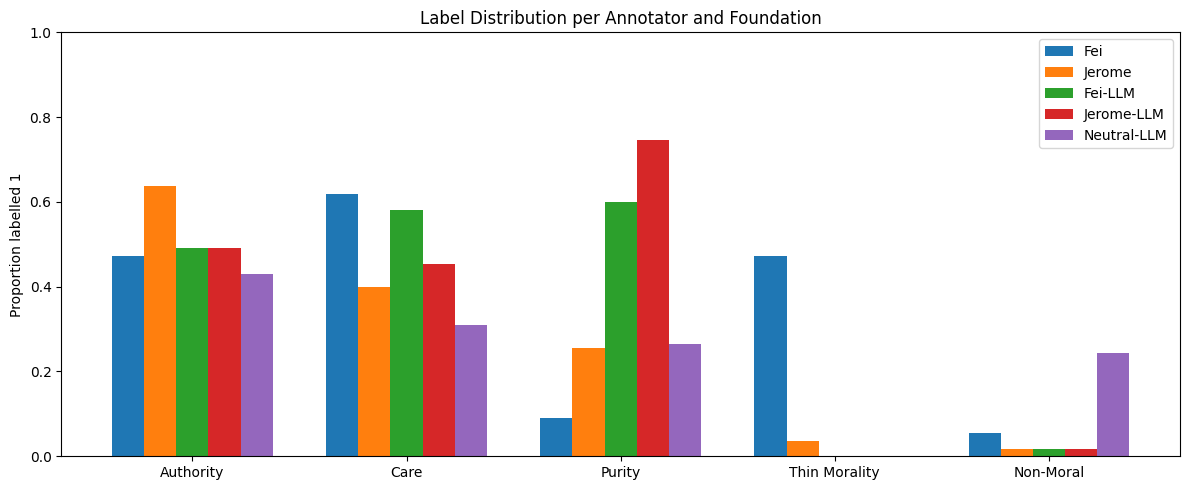

In [53]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

FOUNDATIONS = ['Authority', 'Care', 'Purity', 'Thin Morality', 'Non-Moral']

ANNOTATORS = {
    'Fei':         df_fei,
    'Jerome':      df_jerome,
    'Fei-LLM':     df_llm_fei,
    'Jerome-LLM':  df_llm_jerome,
    'Neutral-LLM': df_llm,
}

# Compute proportion of 1s per annotator per foundation
rows = []
for name, df in ANNOTATORS.items():
    for f in FOUNDATIONS:
        if f in df.columns:
            prop = df[f].mean()
            rows.append({'Annotator': name, 'Foundation': f, 'Proportion': prop})

plot_df = pd.DataFrame(rows)

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
foundations = FOUNDATIONS
annotators  = list(ANNOTATORS.keys())
x = np.arange(len(foundations))
width = 0.15

for i, ann in enumerate(annotators):
    vals = [plot_df[(plot_df['Annotator'] == ann) & (plot_df['Foundation'] == f)]['Proportion'].values[0]
            for f in foundations]
    ax.bar(x + i * width, vals, width, label=ann)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(foundations)
ax.set_ylabel('Proportion labelled 1')
ax.set_title('Label Distribution per Annotator and Foundation')
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150)
plt.show()


In [54]:
# Compare variance in label proportions across foundations per annotator
for name, df in ANNOTATORS.items():
    props = [df[f].mean() for f in ['Authority', 'Care', 'Purity', 'Thin Morality', 'Non-Moral'] if f in df.columns]
    print(f"{name:15s}  mean={np.mean(props):.3f}  std={np.std(props):.3f}")


Fei              mean=0.342  std=0.226
Jerome           mean=0.269  std=0.232
Fei-LLM          mean=0.338  std=0.271
Jerome-LLM       mean=0.342  std=0.290
Neutral-LLM      mean=0.249  std=0.140


In [40]:
def align_and_extract(df_a, df_b, foundation):
    """Merge two annotator dfs on shared item IDs for one foundation."""
    merged = pd.merge(
        df_a[['item_id', foundation]].rename(columns={foundation: 'a'}),
        df_b[['item_id', foundation]].rename(columns={foundation: 'b'}),
        on='item_id', how='inner'
    ).dropna(subset=['a', 'b'])
    return merged['a'].to_numpy(), merged['b'].to_numpy(), merged['item_id'].to_numpy()

def pairwise_alpha(df_a, df_b, foundation):
    """Krippendorff's alpha (nominal) for one foundation between two annotators."""
    a, b, _ = align_and_extract(df_a, df_b, foundation)
    if len(a) < 2:
        return np.nan
    return krippendorff.alpha(np.array([a, b]), level_of_measurement='nominal')

## krippendorf over jerome vs fei vs llm conditions

In [41]:
PAIRS = [
    (df_fei,    df_jerome,     'Human–Human (baseline)'),
    (df_fei,    df_llm_fei,    'Fei vs. Fei-LLM (RQ3 core)'),
    (df_fei,    df_llm,        'Fei vs. Neutral-LLM'),
    (df_fei,    df_llm_jerome, 'Fei vs. Jerome-LLM (wrong profile)'),
    (df_jerome, df_llm_jerome, 'Jerome vs. Jerome-LLM (RQ3 core)'),
    (df_jerome, df_llm_fei,    'Jerome vs. Fei-LLM (wrong profile)'),
    (df_jerome, df_llm,        'Jerome vs. Neutral-LLM'), 
]

alpha_rows = []
for df_a, df_b, label in PAIRS:
    row = [label]
    alphas = []
    for f in ALL_FOUNDATIONS:
        try:
            val = pairwise_alpha(df_a, df_b, f)
        except Exception:
            val = np.nan
        row.append(f"{val:.3f}" if not np.isnan(val) else "n/a")
        if not np.isnan(val):
            alphas.append(val)
    avg = np.mean(alphas) if alphas else np.nan
    row.append(f"{avg:.3f}" if not np.isnan(avg) else "n/a")
    alpha_rows.append(row)

print("TABLE 1: Pairwise Krippendorff's Alpha (nominal, binary labels)")
print(tabulate(alpha_rows,
               headers=['Condition Pair'] + ALL_FOUNDATIONS + ['Avg α'],
               tablefmt='rounded_outline'))

TABLE 1: Pairwise Krippendorff's Alpha (nominal, binary labels)
╭────────────────────────────────────┬─────────────┬──────────┬────────┬─────────╮
│ Condition Pair                     │   Authority │   Purity │   Care │   Avg α │
├────────────────────────────────────┼─────────────┼──────────┼────────┼─────────┤
│ Human–Human (baseline)             │       0.38  │    0.433 │  0.423 │   0.412 │
│ Fei vs. Fei-LLM (RQ3 core)         │       0.603 │   -0.275 │  0.399 │   0.243 │
│ Fei vs. Neutral-LLM                │       0.422 │   -0.304 │  0.301 │   0.139 │
│ Fei vs. Jerome-LLM (wrong profile) │       0.387 │   -0.333 │  0.239 │   0.098 │
│ Jerome vs. Jerome-LLM (RQ3 core)   │       0.414 │    0.027 │  0.374 │   0.272 │
│ Jerome vs. Fei-LLM (wrong profile) │       0.341 │    0.153 │  0.351 │   0.282 │
│ Jerome vs. Neutral-LLM             │       0.38  │    0.063 │  0.239 │   0.227 │
╰────────────────────────────────────┴─────────────┴──────────┴────────┴─────────╯


Analysis of table 1: when giving LLMs profile information they align more with the individual better than without such information and vs an LLM with wrong profile info (Fei vs Fei-LLM is 0.243 compared to vs neutral LLM 0.139 vs jerome-LLM 0.098)

correspondingly Jerome vs Fei-LLM < Jerome vs Jerome-LLM < Jerome vs Neutral-LLM. Jerome vs Fei-LLM is higher only by 0.001 which is likely statisical noise for just 55 items  

this means whatever persona info we're giving does shift the LLM into the direction of the person we describe.

HOWEVER human to human agreement (0.412) is higher than any of the human-LLM comparisons, but even that   has not reached the conventional reliability threshold (>0.667)


## confidence comparison

In [44]:
def confidence_rows(df_human, df_llm_cond, label):
    """Agree/disagree confidence stats for one LLM condition vs one human."""
    conf_map = dict(zip(df_llm_cond['item_id'], df_llm_cond['confidence']))
    rows = []
    for f in ALL_FOUNDATIONS:
        a, b, ids = align_and_extract(df_human, df_llm_cond, f)
        agree_conf, disagree_conf = [], []
        for av, bv, iid in zip(a, b, ids):
            w = CONFIDENCE_WEIGHTS.get(conf_map.get(iid, ''), 0)
            if av == bv:
                agree_conf.append(w)
            else:
                disagree_conf.append(w)
        rows.append([
            label, f,
            f"{np.mean(agree_conf):.3f}"    if agree_conf    else "n/a",
            f"{np.mean(disagree_conf):.3f}" if disagree_conf else "n/a",
            len(agree_conf),
            len(disagree_conf)
        ])
    return rows


conf_rows = []
for df_human, df_llm_cond, label in PAIRS:
    conf_rows.extend(confidence_rows(df_human, df_llm_cond, label))


# After building conf_rows, convert to DataFrame and pivot
conf_df = pd.DataFrame(conf_rows, columns=['Condition', 'Foundation', 'Agree conf', 'Disagree conf', 'N agree', 'N disagree'])

# Build a compact version: one row per condition, foundations as sub-columns
compact = []
for condition, grp in conf_df.groupby('Condition', sort=False):
    row = [condition]
    for f in ALL_FOUNDATIONS:
        r = grp[grp['Foundation'] == f].iloc[0]
        row.append(f"{r['Agree conf']} ({int(r['N agree'])})")
        row.append(f"{r['Disagree conf']} ({int(r['N disagree'])})")
    compact.append(row)

sub_headers = []
for f in ALL_FOUNDATIONS:
    sub_headers += [f'{f} agree', f'{f} disagree']

print("TABLE 2: LLM Confidence on Agreement vs. Disagreement Cases")
print(tabulate(compact, headers=['Condition'] + sub_headers, tablefmt='rounded_outline'))



TABLE 2: LLM Confidence on Agreement vs. Disagreement Cases
╭────────────────────────────────────┬───────────────────┬──────────────────────┬────────────────┬───────────────────┬──────────────┬─────────────────╮
│ Condition                          │ Authority agree   │ Authority disagree   │ Purity agree   │ Purity disagree   │ Care agree   │ Care disagree   │
├────────────────────────────────────┼───────────────────┼──────────────────────┼────────────────┼───────────────────┼──────────────┼─────────────────┤
│ Human–Human (baseline)             │ 0.842 (38)        │ 0.853 (17)           │ 0.837 (46)     │ 0.889 (9)         │ 0.846 (39)   │ 0.844 (16)      │
│ Fei vs. Fei-LLM (RQ3 core)         │ 0.841 (44)        │ 0.773 (11)           │ 0.848 (23)     │ 0.812 (32)        │ 0.821 (39)   │ 0.844 (16)      │
│ Fei vs. Neutral-LLM                │ 0.808 (39)        │ 0.750 (16)           │ 0.900 (20)     │ 0.729 (35)        │ 0.764 (36)   │ 0.842 (19)      │
│ Fei vs. Jerome-LLM (wrong 

In [43]:
for df_a, df_b, label in PAIRS:
    for f in ALL_FOUNDATIONS:
        a, b, ids = align_and_extract(df_a, df_b, f)
        n_disagree = np.sum(a != b)
        pct = n_disagree / len(a) * 100 if len(a) > 0 else 0
        print(f"{label:40s} | {f:15s} | {n_disagree}/{len(a)} disagree ({pct:.0f}%)")


Human–Human (baseline)                   | Authority       | 17/55 disagree (31%)
Human–Human (baseline)                   | Purity          | 9/55 disagree (16%)
Human–Human (baseline)                   | Care            | 16/55 disagree (29%)
Fei vs. Fei-LLM (RQ3 core)               | Authority       | 11/55 disagree (20%)
Fei vs. Fei-LLM (RQ3 core)               | Purity          | 32/55 disagree (58%)
Fei vs. Fei-LLM (RQ3 core)               | Care            | 16/55 disagree (29%)
Fei vs. Neutral-LLM                      | Authority       | 16/55 disagree (29%)
Fei vs. Neutral-LLM                      | Purity          | 35/55 disagree (64%)
Fei vs. Neutral-LLM                      | Care            | 19/55 disagree (35%)
Fei vs. Jerome-LLM (wrong profile)       | Authority       | 17/55 disagree (31%)
Fei vs. Jerome-LLM (wrong profile)       | Purity          | 36/55 disagree (65%)
Fei vs. Jerome-LLM (wrong profile)       | Care            | 21/55 disagree (38%)
Jerome vs. Jerome

## qualitatively checking disagreed text

In [46]:
def get_disagreements(df_human, df_llm_cond, foundation, df_text=None):
    """Return a DataFrame of items where the two annotators disagree on a foundation."""
    a, b, ids = align_and_extract(df_human, df_llm_cond, foundation)
    
    disagree_ids = ids[a != b]
    
    result = pd.DataFrame({
        'item_id': disagree_ids,
        'human': a[a != b],
        'llm':   b[a != b],
    })
    
    # optionally merge in the original text
    if df_text is not None and 'text' in df_text.columns:
        result = result.merge(df_text[['item_id', 'text']], on='item_id', how='left')
    
    return result


In [48]:
dis = get_disagreements(df_fei, df_llm_fei, 'Purity', df_text=df_fei)
print(dis['human'].value_counts())
print(dis['llm'].value_counts())


human
0    30
1     2
Name: count, dtype: int64
llm
1    30
0     2
Name: count, dtype: int64


In [49]:
dis = get_disagreements(df_fei, df_llm_fei, 'Purity', df_text=df_fei)
llm_overannotates = dis[dis['human'] == 0]  # LLM=1, Fei=0
print(llm_overannotates[['item_id', 'text']].to_string())


                item_id                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               text
0  -5935700467771628651                                                                                                                                                                                                                                          &gt;I made everything worse than what it was OP, you didnt make everything worse than what it was. What you did was to shine light on something that was ver